# 基于加权注意力机制预测咖啡受欢迎程度

## 1. 项目背景介绍

咖啡（Coffee）是一种由咖啡豆经过烘焙和冲泡制成的饮料，是世界上最受欢迎的饮品之一。咖啡的起源可以追溯到公元前9世纪的埃塞俄比亚，随后传播到阿拉伯半岛和其他地区。如今，咖啡已经成为全球范围内的重要农产品和经济产业。不同的咖啡品种具有不同的风味特点和口感，这使得人们对于咖啡的品质和受欢迎程度产生了浓厚的兴趣。通过对咖啡的研究，我们可以进一步推动咖啡产业的发展和创新，以满足消费者对于高质量咖啡的需求。了解不同评估指标对咖啡受欢迎程度的影响，可以帮助咖啡生产者和品牌制定更准确的营销策略，提升咖啡产品的竞争力。

本项目将利用机器学习工具和算法对受到群众热烈欢迎的咖啡各方面指标进行探索，以探索出更符合所研究人群口味的新咖啡。我通过调查问卷收集了中国当代20至40岁人群对于咖啡各项评价指标的选择情况的数据。

该数据集中包含2个文件
* coffee_dataset.xlsx：训练数据集
* coffee_test.xlsx：测试数据集合

数据集说明如下：

属性包括13个字段：

| No | 属性         | 数据类型 | 字段描述   | 取值说明 | 
|----|-------------|----------|-----------|-|
| 1  | kind        | String   | 种类      | Arabica、Robusta| 
| 2  | color       | String   | 颜色      | Light Brown、Medium Brown、Dark Brown| 
| 3  | aroma       | String   | 香气      | 花香型（Floral）、水果香型（Fruity）、坚果香型（Nutty）、巧克力香型（Chocolaty）、香料香型（Spicy）、焦糖香型（Caramel）| 
| 4  | acidity     | Numeric  | 明亮度    | 衡量咖啡酸度的指标，取值范围1-100内整数 | 
| 5  | mellow      | String   | 醇厚度    | 轻盈（Light-bodied），中等（Medium-bodied），丰满（Full-bodied）| 
| 6  | aftertaste  | String   | 余韵      | 短暂（Short），中等（Medium），持久（Long）| 
| 7  | sweetness   | String   | 甜度      | 低甜度（Low），中等甜度（Medium），高甜度（High）| 
| 8  | cleanliness | String   | 干净度    | 低干净度（Low），中等干净度（Medium），高干净度（High）| 
| 9  | complexity  | String   | 复杂度    | 低复杂度（Low Complexity），中等复杂度（Medium Complexity），高复杂度（High Complexity）| 
| 10 | foam        | String   | 泡沫      | 无泡沫（No Foam），少量泡沫（Low Foam），适量泡沫（Moderate Foam），多量泡沫（Abundant Foam）| 
| 11 | caffeine    | Numeric  | 咖啡因含量 | 1mg/ml-120mg/ml区间范围内整数 | 
| 12 | brew_method | String   | 冲泡方法   | 滴滤冲泡法（Drip Brewing），压力冲泡法（Pressure Brewing），急速冲泡法（Instant Brewing），水滴冲泡法（Cold Drip Brewing），滤压冲泡法（Immersion Brewing）| 
| 13 | dry_method  | String   | 干燥方法   | 自然干燥（natural），机械干燥（mechanical），太阳能干燥（solar）| 


项目研究目标：
* 哪种特质组合的咖啡更加受欢迎？
* 如何通过已知新产品的各项特征来预测该产品的受欢迎程度？

## 2. 数据清洗和探索

* 导入相关库

In [1]:
import pandas as pd
import numpy as np

* 结构化数据，因此读取并展示前五行数据

In [2]:
# 读取 xlsx 文件数据
coffee_data = pd.read_excel('/home/jovyan/work/datasets/675659647fc08c9152b2572a-momodel/coffee_dataset.xlsx')

# 打印前五行数据
print(coffee_data.head(5))

      kind         color   aroma  acidity         mellow aftertaste sweetness  \
0  Arabica  Medium Brown  Floral        5    Full-bodied       long       low   
1  Robusta   Light Brown   Spicy       60  Medium-bodied     medium       low   
2  Arabica   Light Brown   Nutty        2    Full-bodied       long       low   
3  Arabica   Light Brown   Nutty       10    Full-bodied       long       low   
4  Arabica  Medium Brown  Floral       10    Full-bodied       long       low   

  cleanliness complexity      foam  caffeine       brew_method dry_method  
0        high       high  moderate        50   instant brewing    natural  
1        high       high  moderate        70      drip brewing    natural  
2        high       high       low        40  pressure brewing    natural  
3        high       high       low        50  pressure brewing    natural  
4        high       high  moderate        35   instant brewing    natural  


* 数据预处理

将原始数据集中的范围数据以及字符串型数据用整型来代替，便于后续预测分析

In [3]:
# kind属性中出现了Arabica 和 Robusta两种取值，用 0 代表 Arabica，1 代表 Robusta
coffee_data['kind'].replace({'Arabica': 0, 'Robusta': 1}, inplace=True)

# color属性中出现了Light Brown、Medium Brown、Dark Brown三种取值，分别用0，1，2代替
coffee_data['color'].replace({'Light Brown': 0, 'Medium Brown': 1, 'Dark Brown':2}, inplace=True)

# aroma属性中出现了Floral、Fruity、Nutty、Chocolaty、Spicy、Caramel六种取值，分别用0、1、2、3、4、5代替
coffee_data['aroma'].replace({'Floral': 0, 'Fruity': 1, 'Nutty':2, 'Chocolaty':3, 'Spicy':4, 'Caramel':5}, inplace=True)

# acidity属性为0-100区间范围内整数型取值，设定范围1-50区间内替换为0，50-80区间内替换为1，80-100区间内替换为2
coffee_data['acidity'].replace(range(1, 51), 0, inplace=True)
coffee_data['acidity'].replace(range(50, 81), 1, inplace=True)
coffee_data['acidity'].replace(range(80, 101), 2, inplace=True)

# mellow属性中出现了Light-bodied、Medium-bodied、Full-bodied三种取值，分别用0、1、2代替
coffee_data['mellow'].replace({'Light-bodied': 0, 'Medium-bodied': 1, 'Full-bodied':2}, inplace=True)

# aftertaste属性中出现了Short、Medium、Long三种取值，分别用0、1、2代替
coffee_data['aftertaste'].replace({'short': 0, 'medium': 1, 'long':2}, inplace=True)

# sweetness属性中出现了Low、Medium、High三种取值，分别用0、1、2代替
coffee_data['sweetness'].replace({'low': 0, 'medium': 1, 'high':2}, inplace=True)

# cleanliness属性中出现了Low、Medium、High三种取值，分别用0、1、2代替
coffee_data['cleanliness'].replace({'low': 0, 'medium': 1, 'high':2}, inplace=True)

# complexity属性中出现了Low、Medium、High三种取值，分别用0、1、2代替
coffee_data['complexity'].replace({'low': 0, 'medium': 1, 'high':2}, inplace=True)

# foam属性中出现了No、Low、Moderate、Abundant四种取值，分别用0、1、2、3代替
coffee_data['foam'].replace({'No': 0, 'low': 1, 'moderate':2, 'abundant':3}, inplace=True)

# caffeine属性为0-120区间范围内整数型取值，设定范围0-30区间内替换为0，30-100区间内替换为1，100-120区间内替换为2
coffee_data['caffeine'].replace(range(0, 31), 0, inplace=True)
coffee_data['caffeine'].replace(range(30, 101), 1, inplace=True)
coffee_data['caffeine'].replace(range(100, 121), 2, inplace=True)

# brew_method属性中出现了Drip Brewing、Pressure Brewing、Instant Brewing、Cold Drip Brewing、Immersion Brewing五种取值，分别用0、1、2、3、4代替
coffee_data['brew_method'].replace({'drip brewing': 0, 'pressure brewing': 1, 'instant brewing':2, 'cold drip brewing':3,  'immersion brewing':4}, inplace=True)

# dry_method属性中出现了Natural、Mechanical、Solar三种取值，分别用0、1、2代替
coffee_data['dry_method'].replace({'natural': 0, 'mechanical': 1, 'solar':2}, inplace=True)

/tmp/ipykernel_65/151848246.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  coffee_data['kind'].replace({'Arabica': 0, 'Robusta': 1}, inplace=True)
/tmp/ipykernel_65/151848246.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  coffee_data['kind'].replace({'Arabica': 0, 'Robusta': 1}, inplace=Tr

In [4]:
# 打印前五行数据观察数据预处理结果
print(coffee_data.head(5).to_string(index=False))

 kind  color  aroma  acidity  mellow  aftertaste  sweetness  cleanliness  complexity  foam  caffeine  brew_method  dry_method
    0      1      0        0       2           2          0            2           2     2         1            2           0
    1      0      4        1       1           1          0            2           2     2         1            0           0
    0      0      2        0       2           2          0            2           2     1         1            1           0
    0      0      2        0       2           2          0            2           2     1         1            1           0
    0      1      0        0       2           2          0            2           2     2         1            2           0


* 加入popular属性字段

为了避免后续操作影响原始数据集，这里复制出来一份并加入popular属性，用以统计重复出现的条目数，为后续分析最受欢迎的特征组合做准备

In [5]:
# 复制一份数据集
coffee_copy = coffee_data.copy(deep=True)

coffee_copy['popular'] = coffee_copy.groupby(['kind', 'color', 'aroma', 'acidity', 'mellow', 'aftertaste', 'cleanliness', 'complexity', 'foam', 'caffeine', 'brew_method', 'dry_method'])['kind'].transform('count')
coffee_copy.drop_duplicates(inplace=True)

#print(coffee_copy)

* 查看是否有缺失数据

In [6]:
#np.sum(coffee_copy.isnull())
# 显式指定按列求和，避免警告
np.sum(coffee_copy.isnull(), axis=0)

kind           0
color          0
aroma          0
acidity        0
mellow         0
aftertaste     0
sweetness      0
cleanliness    0
complexity     0
foam           0
caffeine       0
brew_method    0
dry_method     0
popular        0
dtype: int64

可以发现数据集完整，没有丢失数据

* 观察各个属性的最大最小值

In [7]:
coffee_copy['popular'].describe().loc[['min', 'max']]

min      1.0
max    698.0
Name: popular, dtype: float64

In [8]:
# 定义要统计的属性列表
attributes = ['kind', 'color', 'aroma', 'acidity', 'mellow', 'aftertaste', 'sweetness', 'cleanliness', 'complexity','foam','caffeine','brew_method','dry_method']

value_labels = {
    'kind': {0: '0', 1: '1'},
    'color': {0: '0', 1: '1', 2: '2'},
    'aroma': {0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5'},
    'acidity': {0: '0', 1: '1', 2: '2'},
    'mellow': {0: '0', 1: '1', 2: '2'},
    'aftertaste': {0: '0', 1: '1', 2: '2'},
    'sweetness': {0: '0', 1: '1', 2: '2'},
    'cleanliness': {0: '0', 1: '1', 2: '2'},
    'complexity': {0: '0', 1: '1', 2: '2'},
    'foam': {0: '0', 1: '1', 2: '2', 3: '3'},
    'caffeine': {0: '0', 1: '1', 2: '2'},
    'brew_method': {0: '0', 1: '1', 2: '2', 3: '3', 4: '4'},
    'dry_method': {0: '0', 1: '1', 2: '2'},
    
    
}
# 创建空的结果DataFrame
result = pd.DataFrame()

# 打印结果以表格形式展示，包括具体取值
for attribute in attributes:
    print(f"Attribute: {attribute}")
    attribute_counts = coffee_copy[attribute].value_counts(normalize=True).reset_index()
    attribute_counts.columns = ['Value', 'Probability']
    attribute_counts['Value'] = attribute_counts['Value'].map(value_labels[attribute])
    for index, row in attribute_counts.iterrows():
        print(f"Value: {row['Value']}, Probability: {row['Probability']:.2%}")
    print()


# 打印结果以表格形式展示
print(result.to_string(index=False))

Attribute: kind
Value: 1, Probability: 71.79%
Value: 0, Probability: 28.21%

Attribute: color
Value: 2, Probability: 48.72%
Value: 0, Probability: 38.46%
Value: 1, Probability: 12.82%

Attribute: aroma
Value: 5, Probability: 41.03%
Value: 4, Probability: 28.21%
Value: 0, Probability: 17.95%
Value: 1, Probability: 7.69%
Value: 2, Probability: 2.56%
Value: 3, Probability: 2.56%

Attribute: acidity
Value: 0, Probability: 64.10%
Value: 1, Probability: 35.90%

Attribute: mellow
Value: 2, Probability: 51.28%
Value: 1, Probability: 41.03%
Value: 0, Probability: 7.69%

Attribute: aftertaste
Value: 2, Probability: 64.10%
Value: 0, Probability: 23.08%
Value: 1, Probability: 12.82%

Attribute: sweetness
Value: 2, Probability: 64.10%
Value: 0, Probability: 33.33%
Value: 1, Probability: 2.56%

Attribute: cleanliness
Value: 2, Probability: 79.49%
Value: 1, Probability: 20.51%

Attribute: complexity
Value: 2, Probability: 84.62%
Value: 1, Probability: 15.38%

Attribute: foam
Value: 2, Probability: 58

观察popular属性的取值情况和概率

In [9]:
# 统计popular属性的取值频次
popular_counts = coffee_copy['popular'].value_counts().reset_index()
popular_counts.columns = ['Value', 'Count']

# 按照取值从小到大排序
popular_counts = popular_counts.sort_values(by='Value')

# 打印popular属性的取值情况
print("Popular Value Counts:")
print(popular_counts)

Popular Value Counts:
    Value  Count
0       1      6
2       2      4
1       3      4
3       4      4
21      5      1
4       6      3
18     13      1
6      15      1
17     16      1
20     17      1
10     21      1
14     23      1
16     45      1
8      53      1
5      55      2
15     56      1
7      57      1
19     98      1
12    102      1
13    299      1
9     317      1
11    698      1


打印一下popular中值较大的数据条目，即为较受欢迎的组合

In [10]:
# 打印popular属性值为698的数据条目
print("popular=698")
popular_698_data = coffee_copy[coffee_copy['popular'] == 698].drop('popular', axis=1)
print(popular_698_data.to_string(index=False))


print("=======================================================")
print("popular=317")
popular_317_data = coffee_copy[coffee_copy['popular'] == 317].drop('popular', axis=1)
print(popular_317_data.to_string(index=False))


print("=======================================================")
print("popular=299")
popular_299_data = coffee_copy[coffee_copy['popular'] == 299].drop('popular', axis=1)
print(popular_299_data.to_string(index=False))


print("=======================================================")
print("popular=102")
popular_102_data = coffee_copy[coffee_copy['popular'] == 102].drop('popular', axis=1)
print(popular_102_data.to_string(index=False))

popular=698
 kind  color  aroma  acidity  mellow  aftertaste  sweetness  cleanliness  complexity  foam  caffeine  brew_method  dry_method
    0      1      0        0       2           2          0            2           2     2         1            2           0
popular=317
 kind  color  aroma  acidity  mellow  aftertaste  sweetness  cleanliness  complexity  foam  caffeine  brew_method  dry_method
    0      0      2        0       2           2          0            2           2     1         1            1           0
popular=299
 kind  color  aroma  acidity  mellow  aftertaste  sweetness  cleanliness  complexity  foam  caffeine  brew_method  dry_method
    0      2      3        0       2           2          1            2           2     3         0            3           0
popular=102
 kind  color  aroma  acidity  mellow  aftertaste  sweetness  cleanliness  complexity  foam  caffeine  brew_method  dry_method
    1      0      4        1       1           0          0           

为了后续方便进行分类预测，我们设置一个popular_level，规定如下：

* popular > 10：受欢迎，1
* poplar <= 10: 不太受欢迎，0

【说明】：由于调查问卷中范围较小，因此若10个人对于自己喜爱咖啡的特征选择相同，即可认为这一类咖啡是受欢迎的

In [11]:
# 创建新的属性列 popular_level，并根据 popular 列的取值进行分类
coffee_copy['popular_level'] = np.where(coffee_copy['popular'] > 10, 1, 0)

# 转换为整数类型，这样后面的热力图可以展示该属性列
coffee_copy['popular_level'] = coffee_copy['popular_level'].astype(int)

# 打印结果
#print(coffee_copy)
#print(coffee_copy[['popular', 'popular_level']])

In [12]:
print(coffee_copy['popular_level'].dtype)

int64


## 3. 数据可视化分析

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['SimHei']  # 中文字体设置-黑体
plt.rcParams['axes.unicode_minus'] = False  # 解决保存图像是负号'-'显示为方块的问题
plt.figure(dpi=100, figsize=(10, 5))# 设置图片大小
coffee_without_popular = coffee_copy.drop("popular", axis=1)  # 去掉属性列"popular"
sns.heatmap(coffee_without_popular.corr(), annot=True, fmt='.2f')

Duplicate key in file PosixPath('/usr/local/lib/python3.9/dist-packages/matplotlib/mpl-data/matplotlibrc'), line 801 ('font.family: sans-serif')
Duplicate key in file PosixPath('/usr/local/lib/python3.9/dist-packages/matplotlib/mpl-data/matplotlibrc'), line 802 ('font.sans-serif: SimHei')


<Axes: >

热力图可以反映两个属性之间的相关性大小，方块颜色越浅则代表正相关性越大，颜色越深则表示负相关性越大，如果图中发现某两个属性之间正相关性较大，则说明根据前面收集到的用户偏好数据，可以得出结论，当用户选择某种属性的特定值时，更倾向于另一个属性为某种选择，即这种正相关性反映了用户的偏好和选择模式。

例如：若kind和sweetness间正相关性较大，可以得出结论，当用户选择一种特定的咖啡种类时，他们更倾向于选择特定的甜度水平。这可以用来推断，对于所采集数据的用户群体来说，特定的咖啡种类和甜度水平的组合更受欢迎。这种观察可以用于定制咖啡产品或推荐系统，以满足用户的偏好和需求。

根据热力图寻找咖啡相关评估指标间正相关性较大的属性关系

In [ ]:
# 筛选相关性大于0.5的属性间关系（不包括对角线）
threshold = 0.5
correlation_matrix = coffee_copy.corr()
high_correlation = correlation_matrix[(correlation_matrix > threshold) & (correlation_matrix < 1.0)]
high_correlation = high_correlation.dropna(how='all', axis=1).dropna(how='all', axis=0)

# 按相关性大小从大到小进行排序
high_correlation_sorted = high_correlation.stack().sort_values(ascending=False)

# 打印排序结果，转换为元组形式并去除重复元组，不打印包含 'popular' 和 'popular_level' 属性的元组
unique_tuples = set()
for idx, value in high_correlation_sorted.items():
    attr1, attr2 = idx
    if ('popular' in (attr1, attr2)) or ('popular_level' in (attr1, attr2)):
        continue
    if (attr2, attr1) not in unique_tuples:
        unique_tuples.add((attr1, attr2))
        print((attr1, attr2, value))


('color', 'sweetness', 0.759105883056075)
('mellow', 'color', 0.7103981477485906)
('aroma', 'foam', 0.7017860608468177)
('sweetness', 'brew_method', 0.6447184635045164)
('aftertaste', 'sweetness', 0.5892087279631189)
('aftertaste', 'brew_method', 0.5298043616513773)


寻找影响popular_level较为显著的属性

In [ ]:
# 设置相关性阈值
threshold = 0.2

# 获取与特定属性 'popular_level' 相关性大于阈值的属性，不包括popular属性和自身
correlation_matrix = coffee_copy.corr()
related_attributes = correlation_matrix['popular_level'][(correlation_matrix['popular_level'] > threshold) & (correlation_matrix.columns != 'popular') 
 & (correlation_matrix.columns != 'popular_level')].index.tolist()

# 打印相关属性
print("与 'popular_level' 相关性大于 0.2 的属性:")
print(related_attributes)


与 'popular_level' 相关性大于 0.2 的属性:
['cleanliness', 'complexity', 'brew_method']


## 4. 预测咖啡受欢迎程度

### 4.1 模型的构建和训练

In [16]:
import mindspore as ms
import mindspore.nn as nn
import mindspore.dataset as ds
from mindspore import Model
from mindspore.train.callback import LossMonitor

In [17]:
# 将 coffee_modified 中的 DataFrame对象转换为适合 MindSpore 框架的 Tensor 格式，同时去掉无用的popular列，只保留popular_level
coffee_tensor = coffee_copy.drop('popular', axis=1)
coffee_tensor = ms.Tensor(coffee_tensor.values, ms.float32) 

print(coffee_tensor.dtype)
print(coffee_tensor.shape)
#print(coffee_tensor)

Float32
(39, 14)


接下来，将特征列和标签列分离开来

* 特征列：包括13个关于咖啡的属性，用来描述每个样本的特征信息，可以称为输入变量
* 标签列：用于表示每个样本受欢迎程度的列，可以称为输出变量

下面我们根据热力图中得到各个属性与popular_level之间的正相关性大小来赋予各属性不同的权重

In [18]:
#selected_columns = ['color','aroma','mellow','aftertaste','sweetness','foam','brew_method','popular_level']
#selected_columns = ['cleanliness', 'complexity', 'brew_method']

# 定义属性权重, 对应位置属性赋予更大的权重
attribute_weights = ms.Tensor([1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 3.0, 3.0, 1.0, 1.0, 3.0, 1.0], dtype=ms.float32)

# 特征列索引为0到4，标签列索引为5
features = coffee_tensor[:, :13]
labels = coffee_tensor[:, 13].astype(np.int32)

下面自定义模型，并嵌入了加性注意力模块

In [19]:
import mindspore as ms
import mindspore.nn as nn
import mindspore.ops as ops


#加性注意力
class AttentionLayer(nn.Cell):
    def __init__(self, input_dim, output_dim):  # 修改构造函数，接收输出维度
        super(AttentionLayer, self).__init__()
        self.fc = nn.Dense(input_dim, output_dim)  # 后面训练模型时，创建AttentionLayer实例时，传入参数
        self.softmax = nn.Softmax(axis=1)  #对注意力权重进行归一化，使得注意力权重之和等于1

    def construct(self, x):
        attention_scores = self.fc(x)
        attention_weights = self.softmax(attention_scores)
        attended_features = attention_weights * x * attention_weights
        return attended_features

    
class MyModel(nn.Cell):
    def __init__(self, num_features, num_classes, attribute_weights):
        super(MyModel, self).__init__()
        self.fc1 = nn.Dense(num_features, 64)
        self.relu1 = nn.ReLU()
        self.attention_layer = AttentionLayer(64, 64)  # 修改输出维度为 64
        self.fc2 = nn.Dense(64, num_classes)
        self.attribute_weights = attribute_weights

    def construct(self, x):
        x = self.fc1(x)
        x = self.relu1(x)

        x = self.attention_layer(x)
        x = self.fc2(x)

        return x

In [20]:
# 创建模型实例
model = MyModel(num_features=13, num_classes=2, attribute_weights=attribute_weights)

# 定义损失函数
loss = nn.SoftmaxCrossEntropyWithLogits(sparse=True, reduction='mean')

# 定义优化器
optimizer = nn.Adam(model.trainable_params(), learning_rate=0.001)

# 创建WithLossCell
network_with_loss = nn.WithLossCell(model, loss)

# 创建TrainOneStepCell
train_network = nn.TrainOneStepCell(network_with_loss, optimizer)


WithLossCell是一个包装器，用于将模型和损失函数组合在一起，形成一个整体的网络单元。它将输入数据经过模型的前向传播计算得到预测结果，然后将预测结果与标签数据一起输入到损失函数中计算损失值。将模型和损失函数封装在一个单元中，方便统一调用，避免了重复编写前向传播和计算损失的代码。同时，它还可以自动处理梯度的计算和反向传播过程，简化了模型训练的过程。

TrainOneStepCell是用于执行单步训练的网络单元Cell。它包含模型和损失函数的nn.WithLossCell对象和优化器一起组合，形成一个可直接进行训练的网络单元。在每一步训练中，只需要调用该单元的train_step方法，传入输入数据和标签数据，它将自动执行前向传播、损失计算、反向传播和参数更新等操作，进一步简化了模型训练的代码，使得训练过程更加清晰和高效。

使用WithLossCell和TrainOneStepCell可以方便地将模型、损失函数和优化器组合在一起，简化了模型训练的流程，提高了代码的可读性和可维护性，同时还减少了错误的可能性。

In [21]:
# 数据预处理和转换
def preprocess_data(features, labels):
    features = features.astype(np.float32)
    labels = labels.astype(np.int32)
    return ms.Tensor(features), ms.Tensor(labels)

# 定义训练过程
def train(train_network, features, labels, epochs):
    features, labels = preprocess_data(features, labels)

    for epoch in range(epochs):
        epoch_loss = 0.0

        # 执行一次训练
        loss = train_network(features, labels)

        epoch_loss = loss.asnumpy()
        #print("Epoch: {}, Loss: {}".format(epoch, epoch_loss))

# 假设训练10个epochs
train(train_network, features, labels, epochs=100)

下面展示模型结构

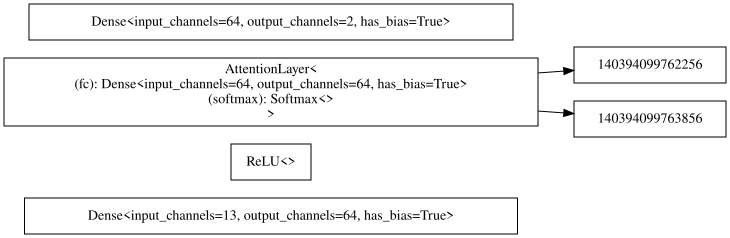

In [22]:
from graphviz import Digraph

# 生成模型结构的树形图
dot = Digraph()
dot.attr(rankdir='LR')  # 设置图的方向，从左到右
dot.node_attr.update(shape='box')  # 设置节点的形状为矩形

# 遍历模型的子模块，生成节点和边
for cell in model.cells():
    dot.node(str(id(cell)), str(cell))
    for subcell in cell.cells():
        dot.edge(str(id(cell)), str(id(subcell)))

# 展示树形图
dot

这里我们设计了一个具有加权注意力机制的神经网络模型。该模型由两个主要部分组成：AttentionLayer和MyModel。

AttentionLayer是注意力机制的实现。它接收输入特征并计算注意力分数，然后对注意力分数进行归一化处理，得到注意力权重。最后，利用注意力权重对输入特征进行加权求和，生成加权特征表示。

MyModel是整个神经网络模型的主体部分。它由一个全连接层（fc1）和一个ReLU激活函数（relu1）组成，用于提取输入特征的高级表示。然后，通过AttentionLayer对提取的特征进行注意力加权，得到加权特征表示。最后，再经过一个全连接层（fc2）生成最终的输出结果。

损失函数部分，我使用了SoftmaxCrossEntropyWithLogits作为损失函数，设置sparse=True表示标签是稀疏的，reduction='mean'表示将样本损失的均值作为最终的损失值。SoftmaxCrossEntropyWithLogits常常用于多分类问题，但是针对本项目的二分类问题，也可以使用SoftmaxCrossEntropyWithLogits来度量模型预测结果与真实标签之间的差距，并进行优化。在二分类问题中，通常使用一个输出节点来表示两个类别的概率。SoftmaxCrossEntropyWithLogits会将输出节点的结果经过Softmax函数处理，将其转换为两个类别的概率分布，并计算交叉熵损失，结合了Softmax函数和交叉熵损失，能够有效地衡量模型的分类性能。

优化器部分，我选择了Adam优化器，它是一种自适应学习率的优化算法，能够根据参数的梯度自动调整学习率。通过调用model.trainable_params()获取可训练参数，将其作为优化器的参数。同时设置了学习率为0.001。

为什么要这样构建模型呢？

选择设计这样的模型结构的原因是，注意力机制可以帮助模型更加关注输入特征中的重要部分，从而提高模型的性能和表达能力。通过热力图我们也发现了，有些属性对于最后popular_level的预测影响较大，有些属性两两之间的正相关性较大，通过引入AttentionLayer，模型可以自动学习特征之间的关联性，并对不同特征进行加权处理，以便更好地捕捉输入数据中的重要信息。通过使用全连接层和ReLU激活函数，模型能够进行非线性变换和特征提取，增强模型的表示能力。最后，通过全连接层将提取的特征映射到输出空间，实现对输入数据的分类或回归预测。

这样的模型结构能够有效地利用输入特征之间的关系和重要性，提高模型的表现力和泛化能力，适用于各种结构化数据的分类或回归任务。

### 4.2 利用模型预测

In [23]:
# 读取 xlsx 文件数据
coffee_test = pd.read_excel('/home/jovyan/work/datasets/675659647fc08c9152b2572a-momodel/coffee_test.xlsx')

#print(coffee_test)

In [24]:
## 处理测试集数据
coffee_test['kind'].replace({'Arabica': 0, 'Robusta': 1}, inplace=True)

coffee_test['color'].replace({'Light Brown': 0, 'Medium Brown': 1, 'Dark Brown':2}, inplace=True)

coffee_test['aroma'].replace({'Floral': 0, 'Fruity': 1, 'Nutty':2, 'Chocolaty':3, 'Spicy':4, 'Caramel':5}, inplace=True)

coffee_test['acidity'].replace(range(1, 51), 0, inplace=True)
coffee_test['acidity'].replace(range(50, 81), 1, inplace=True)
coffee_test['acidity'].replace(range(80, 101), 2, inplace=True)

coffee_test['mellow'].replace({'Light-bodied': 0, 'Medium-bodied': 1, 'Full-bodied':2}, inplace=True)

coffee_test['aftertaste'].replace({'short': 0, 'medium': 1, 'long':2}, inplace=True)

coffee_test['sweetness'].replace({'low': 0, 'medium': 1, 'high':2}, inplace=True)

coffee_test['cleanliness'].replace({'low': 0, 'medium': 1, 'high':2}, inplace=True)

coffee_test['complexity'].replace({'low': 0, 'medium': 1, 'high':2}, inplace=True)

coffee_test['foam'].replace({'No': 0, 'low': 1, 'moderate':2, 'abundant':3}, inplace=True)

coffee_test['caffeine'].replace(range(0, 31), 0, inplace=True)
coffee_test['caffeine'].replace(range(30, 101), 1, inplace=True)
coffee_test['caffeine'].replace(range(100, 121), 2, inplace=True)

coffee_test['brew_method'].replace({'drip brewing': 0, 'pressure brewing': 1, 'instant brewing':2, 'cold drip brewing':3,  'immersion brewing':4}, inplace=True)

coffee_test['dry_method'].replace({'natural': 0, 'mechanical': 1, 'solar':2}, inplace=True)

#print(coffee_test)

/tmp/ipykernel_65/2019219167.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  coffee_test['kind'].replace({'Arabica': 0, 'Robusta': 1}, inplace=True)
/tmp/ipykernel_65/2019219167.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  coffee_test['kind'].replace({'Arabica': 0, 'Robusta': 1}, inplace=

In [25]:
# 将测试数据转换为Tensor格式
test_data = ms.Tensor(coffee_test.values, ms.float32)

# 提取特征
test_features = test_data[:, :13]

# 使用训练好的模型进行预测
predictions = model(test_features)

# 将预测结果转换为类别标签
predicted_labels = np.argmax(predictions, axis=1)

## 5. 模型的评估和改进

使用准确率（Accuracy）对模型指令进行评估

原因：
* 准确率（Accuracy）是评估分类模型常用的指标之一，它可以反映模型分类预测的准确程度。选择准确率作为评估指标的原因是，对于分类问题，关注模型正确分类的样本比例，准确率能直观地表示模型的分类性能。

In [26]:
import mindspore as ms
import mindspore.nn as nn
import mindspore.ops as ops

# 比较预测类别与真实标签，计算预测正确的样本数
true_label = coffee_test['popular_level'].values
correct_predictions = np.sum(predicted_labels == true_label)
# 计算准确率
accuracy = correct_predictions / len(true_label)

print("Test Accuracy: {:.4f}".format(accuracy))

Test Accuracy: 0.5556


评估指标显示模型指令并不高，猜想原因有以下：

* 数据预处理部分仅仅通过手动映射将字符串型数据映射为了整型，这样映射可能会产生一些偏好关系，可以考虑独热编码

* 权重赋予不得当

* 数据集过少，由于是调查问卷收集，所涉及人群集中在笔者所在城市和相近年轻区间，不够全面；同时2005个数据可能会使得模型训练不够

下面尝试进行改进：
取消属性的权重数组，让模型自主通过数据集来学习和更新参数

In [27]:
# 特征列索引为0到12，标签列索引为13
features = coffee_tensor[:, :13]
labels = coffee_tensor[:, 13].astype(np.int32)

In [28]:
import mindspore as ms
import mindspore.nn as nn
import mindspore.ops as ops


#加性注意力
class AttentionLayer(nn.Cell):
    def __init__(self, input_dim, output_dim):  # 修改构造函数，接收输出维度
        super(AttentionLayer, self).__init__()
        self.fc = nn.Dense(input_dim, output_dim)  # 后面训练模型时，创建AttentionLayer实例时，传入参数
        self.softmax = nn.Softmax(axis=1)  #对注意力权重进行归一化，使得注意力权重之和等于1

    def construct(self, x):
        attention_scores = self.fc(x)
        attention_weights = self.softmax(attention_scores)
        attended_features = attention_weights * x
        return attended_features

    
class MyModel(nn.Cell):
    def __init__(self, num_features, num_classes):
        super(MyModel, self).__init__()
        self.fc1 = nn.Dense(num_features, 64)
        self.relu1 = nn.ReLU()
        # self.fc2 = nn.Dense(64, num_classes)
        self.fc2 = nn.Dense(64, num_classes)

        self.attention_layer = AttentionLayer(64, 64)  # 修改输出维度为 64

    def construct(self, x):
        x = self.fc1(x)
        x = self.relu1(x)

        x = self.attention_layer(x)
        x = self.fc2(x)

        return x


In [29]:
# 创建模型实例
model = MyModel(num_features=13, num_classes=2)  # 后续训练好的模型和参数保存在这个对象中

# 定义损失函数
loss = nn.SoftmaxCrossEntropyWithLogits(sparse=True, reduction='mean')
#loss = nn.SoftMarginLoss(reduction='mean')

# 定义优化器
optimizer = nn.Adam(model.trainable_params(), learning_rate=0.001)

# 创建WithLossCell
network_with_loss = nn.WithLossCell(model, loss)

# 创建TrainOneStepCell
train_network = nn.TrainOneStepCell(network_with_loss, optimizer)

In [30]:
# 数据预处理和转换
def preprocess_data(features, labels):
    features = features.astype(np.float32)
    labels = labels.astype(np.int32)
    return ms.Tensor(features), ms.Tensor(labels)

# 定义训练过程
def train(train_network, features, labels, epochs):
    features, labels = preprocess_data(features, labels)

    for epoch in range(epochs):
        epoch_loss = 0.0

        # 执行一次训练
        loss = train_network(features, labels)

        epoch_loss = loss.asnumpy()
        #print("Epoch: {}, Loss: {}".format(epoch, epoch_loss))
        
# 假设训练10个epochs
train(train_network, features, labels, epochs=100)

In [31]:
# 保存模型
ms.save_checkpoint(model, "/home/jovyan/work/model.ckpt")

加载模型进行预测

In [32]:
import mindspore as ms
import mindspore.nn as nn
import mindspore.ops as ops

#加性注意力
class AttentionLayer(nn.Cell):
    def __init__(self, input_dim, output_dim):  # 修改构造函数，接收输出维度
        super(AttentionLayer, self).__init__()
        self.fc = nn.Dense(input_dim, output_dim)  # 后面训练模型时，创建AttentionLayer实例时，传入参数
        self.softmax = nn.Softmax(axis=1)  #对注意力权重进行归一化，使得注意力权重之和等于1

    def construct(self, x):
        attention_scores = self.fc(x)
        attention_weights = self.softmax(attention_scores)
        attended_features = attention_weights * x
        return attended_features

    
class MyModel(nn.Cell):
    def __init__(self, num_features, num_classes):
        super(MyModel, self).__init__()
        self.fc1 = nn.Dense(num_features, 64)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Dense(64, num_classes)
        self.attention_layer = AttentionLayer(64, 64)  # 修改输出维度为 64

    def construct(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.attention_layer(x)
        x = self.fc2(x)

        return x


# 创建模型实例
model = MyModel(num_features=13, num_classes=2)

# 加载模型参数
param_dict = ms.load_checkpoint("model.ckpt")
ms.load_param_into_net(model, param_dict)

([], [])

In [33]:
# 将测试数据转换为Tensor格式
test_data = ms.Tensor(coffee_test.values, ms.float32)

# 提取特征
test_features = test_data[:, :13]

# 使用训练好的模型进行预测
predictions = model(test_features)

# 将预测结果转换为类别标签
predicted_labels = np.argmax(predictions, axis=1)

# 比较预测类别与真实标签，计算预测正确的样本数
true_label = coffee_test['popular_level'].values
correct_predictions = np.sum(predicted_labels == true_label)
# 计算准确率
accuracy = correct_predictions / len(true_label)

print("Test Accuracy: {:.4f}".format(accuracy))

Test Accuracy: 0.7778


可以看到模型准确率得到提升，模型质量得到提高

通过查阅资料了解到，前面数据预处理时直接将属性值映射为数值类型，然后进行模型训练是不够合理的，存在以下缺点：

* 引入了偏好和大小关系：将属性值映射为数值类型可能会引入属性值之间的偏好和大小关系，这在某些情况下可能是不合适的。例如，如果将一个有序的属性值（如大小：小、中、大）直接映射为数值类型，模型可能会错误地认为大小之间存在数值上的关系。

* 引入了偏好和间距关系：将属性值映射为数值类型时，模型可能会认为0、1、2这种分类编号之间1的间距与最后的预测结果有一定影响

* 增加了维度和稀疏性：直接映射为数值类型会增加数据的维度，并且可能导致稀疏性问题。例如，如果一个属性有很多不同的取值，将其映射为数值类型会导致数据集中存在大量的零值，从而增加计算和存储的负担。

为了消除引入的偏好关系、保持离散性和可解释性，考虑进行独热编码

【注意】：
* 在进行独热编码之前，需要先将属性值映射为数值类型，然后再应用独热编码。这样做是为了确保属性值是可比较和可计算的。

* 对于字符串类型的属性，可以使用字典或其他映射方式将其转换为数值类型。然后，对转换后的数值进行独热编码，以获得每个类别的二进制编码表示。

下面给出了模型构建时采用独热编码的代码

In [34]:
import mindspore as ms
import mindspore.nn as nn
import mindspore.ops as ops
import numpy as np

class MyModel(nn.Cell):
    def __init__(self, num_features, num_classes):
        super(MyModel, self).__init__()

        self.fc1 = nn.Dense(num_features, 128)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Dense(128, 64)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Dense(64, 32)
        self.relu3 = nn.ReLU()
        self.fc4 = nn.Dense(32, num_classes)

        self.one_hot_encodings = {
            'kind': ops.OneHot(2),
            'color': ops.OneHot(3),
            'aroma': ops.OneHot(6),
            'acidity': ops.OneHot(3),
            'mellow': ops.OneHot(3),
            'aftertaste': ops.OneHot(3),
            'sweetness': ops.OneHot(3),
            'cleanliness': ops.OneHot(3),
            'complexity': ops.OneHot(3),
            'foam': ops.OneHot(4),
            'caffeine': ops.OneHot(3),
            'brew_method': ops.OneHot(5),
            'dry_method': ops.OneHot(3)
        }

    def construct(self, x):
        x_kind = self.one_hot_encodings['kind'](x[:, 0])
        x_color = self.one_hot_encodings['color'](x[:, 1])
        x_aroma = self.one_hot_encodings['aroma'](x[:, 2])
        x_acidity = self.one_hot_encodings['acidity'](x[:, 3])
        x_mellow = self.one_hot_encodings['mellow'](x[:, 4])
        x_aftertaste = self.one_hot_encodings['aftertaste'](x[:, 5])
        x_sweetness = self.one_hot_encodings['sweetness'](x[:, 6])
        x_cleanliness = self.one_hot_encodings['cleanliness'](x[:, 7])
        x_complexity = self.one_hot_encodings['complexity'](x[:, 8])
        x_foam = self.one_hot_encodings['foam'](x[:, 9])
        x_caffeine = self.one_hot_encodings['caffeine'](x[:, 10])
        x_brew_method = self.one_hot_encodings['brew_method'](x[:, 11])
        x_dry_method = self.one_hot_encodings['dry_method'](x[:, 12])

        # 将经过独热编码后的属性特征按列进行连接，形成最终的特征向量 x
        x = ms.ops.Concat(axis=1)([x_kind, x_color, x_aroma, x_acidity, x_mellow, x_aftertaste, x_sweetness,
                                   x_cleanliness, x_complexity, x_foam, x_caffeine, x_brew_method, x_dry_method])

        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        x = self.relu3(x)
        x = self.fc4(x)

        return x